In [12]:
import cv2
import torch
import numpy as np
import pandas as pd
from PIL import Image
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [14]:
# Getting Train Transforms 

def get_train_transforms():
    return transforms.Compose(
        [
            transforms.Resize((256, 256)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(20),
            transforms.RandomAffine(0),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]
    )

In [15]:
# Getting Test Transforms

def get_test_transforms():
    return transforms.Compose(
        [
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ]
    )

In [16]:
# Getting DataLoaders

def get_data(train_path, test_path, batch_size):

    train_set = ImageFolder(root = train_path, transform = get_train_transforms())
    test_set = ImageFolder(root = test_path, transform = get_test_transforms())

    train_loader = DataLoader(train_set, batch_size = batch_size, shuffle = True, num_workers = 2, pin_memory = True)
    test_loader = DataLoader(test_set, batch_size = batch_size, num_workers = 2, pin_memory = True)

    return {
        "train_loader":train_loader,
        "test_loader":test_loader
    }

In [17]:
# CNN Class Architecture

class CNN(nn.Module):
    def __init__(self):
        super (CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            # 1st Layer
            nn.Conv2d(3, 128, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # 2nd Layer
            nn.Conv2d(128, 256, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # 3rd Layer
            nn.Conv2d(256, 512, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.fc_layers = nn.Sequential(
            # 1st Layer
            nn.Linear(32*32*512, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            # 2nd Layer
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # 3rd Layer
            nn.Linear(128, 32),
            nn.ReLU(),

            # Output Layer
            nn.Linear(32, 4)
        )

    def forward(self, x):

        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)

        return x

In [18]:
# CNN Training Architecture

train_losses = []
val_losses = []

def train_model(model, train_loader, test_loader, criterion, optimizer, epochs):

    train_losses.clear()
    val_losses.clear()
    best_loss = float("inf")

    for epoch in range(epochs):

        model.train()
        running_train_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
        epoch_train_loss = running_train_loss / len(train_loader)
        train_losses.append(epoch_train_loss)

        # Validation on Testing Data

        model.eval()
        with torch.no_grad():

            running_val_loss = 0.0

            for images, labels in test_loader:

                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                
                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item()
            epoch_val_loss = running_val_loss / len(test_loader)
            val_losses.append(epoch_val_loss)

        print(f"Epoch = {epoch + 1}/{epochs} ==> Training Loss = {epoch_train_loss} ==> Validation Loss = {epoch_val_loss}")
    
        if epoch_val_loss < best_loss:
            best_loss = epoch_val_loss
            if isinstance(model, nn.DataParallel):
                torch.save(model.module.state_dict(), "best_model.pth")
            else:
                torch.save(model.state_dict(), "best_model.pth")
            
    print(f"\nBest Loss = {best_loss}")

    plt.plot(train_losses, label = "Training Loss")
    plt.plot(val_losses, label = "Validation Loss")

    plt.xlabel("Epochs")
    plt.ylabel("Loss")

    plt.legend()
    plt.show()

In [19]:
# Evaluation 

def evaluate(model, loader):

    correct_labels = 0
    total_labels = 0

    all_labels = []
    all_predictions = []

    model.eval()
    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
    
            outputs = model(images)
            _,predicted = torch.max(outputs, 1)
            correct_labels += (predicted == labels).sum().item()
            total_labels += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    accuracy = (correct_labels / total_labels)*100
    print(f"Accuracy : {accuracy:.2f}%")

    return all_labels, all_predictions

In [20]:
def predict_image(model, image_path, class_names):

    model.eval()
    
    # Load Image
    image = Image.open(image_path).convert("RGB")

    # Transform
    transform = get_test_transforms()
    image = transform(image)

    # Batch Dimension
    image = image.unsqueeze(0)
    image = image.to(device)

    with torch.no_grad():

        outputs = model(image)
        probabilities = torch.softmax(outputs, 1)
        predicted_class = torch.argmax(probabilities, 1)

    print("\nPrediction Probabilities\n")

    for i, class_name in enumerate(class_names):

        confidence = probabilities[0][i].item() * 100
        
        print(f"{class_name:<12}: {confidence:.2f}%")

    print("\n----------------------------------")

    print(
        f"Predicted Class : {class_names[predicted_class.item()]}"
    )

In [21]:
# Main Pipeline

def main():

    data = get_data(
        "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training",
        "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing",
        64
    )

    model = CNN()

    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs")
        model = nn.DataParallel(model)

    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr = 0.001, weight_decay = 5e-4)

    train_model(
        model,
        data["train_loader"],
        data["test_loader"],
        criterion, 
        optimizer,
        100
    )

    weights = torch.load("best_model.pth", map_location=device)

    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(weights)
    else:
        model.load_state_dict(weights)

    print("Training Metrics\n")
    
    train_true_labels, train_predictions = evaluate(
        model,
        data["train_loader"]
    )

    print(classification_report(
        train_true_labels, 
        train_predictions,
        target_names = data["train_loader"].dataset.classes
    ), "\n\n")

    train_cm = confusion_matrix(train_true_labels, train_predictions)
    train_disp = ConfusionMatrixDisplay(
        confusion_matrix = train_cm,
        display_labels = data["train_loader"].dataset.classes
    )

    print(train_cm)

    train_disp.plot(cmap = "Blues")
    plt.show()

    print("Testing Metrics\n")

    test_true_labels, test_predictions = evaluate(
        model,
        data["test_loader"]
    )

    print(classification_report(
        test_true_labels, 
        test_predictions,
        target_names = data["test_loader"].dataset.classes
    ), "\n\n")

    test_cm = confusion_matrix(test_true_labels, test_predictions)
    test_disp = ConfusionMatrixDisplay(
        confusion_matrix = test_cm,
        display_labels = data["test_loader"].dataset.classes
    )

    print(test_cm)

    test_disp.plot(cmap = "Blues")
    plt.show()

Using 2 GPUs
Epoch = 1/100 ==> Training Loss = 3.5427124947309494 ==> Validation Loss = 1.1732315158843993
Epoch = 2/100 ==> Training Loss = 1.0752292343161323 ==> Validation Loss = 1.0229200387001038
Epoch = 3/100 ==> Training Loss = 0.9034203663468361 ==> Validation Loss = 0.8426741969585418
Epoch = 4/100 ==> Training Loss = 0.7979135628451001 ==> Validation Loss = 0.8474460566043853
Epoch = 5/100 ==> Training Loss = 0.7427879341624 ==> Validation Loss = 0.7754189151525498
Epoch = 6/100 ==> Training Loss = 0.6933792599222877 ==> Validation Loss = 0.8135311484336853
Epoch = 7/100 ==> Training Loss = 0.6422259516336701 ==> Validation Loss = 0.7372345435619354
Epoch = 8/100 ==> Training Loss = 0.6438557177104733 ==> Validation Loss = 0.8832534164190292
Epoch = 9/100 ==> Training Loss = 0.6095424517989159 ==> Validation Loss = 0.8317378187179565
Epoch = 10/100 ==> Training Loss = 0.579326331615448 ==> Validation Loss = 0.817818530201912
Epoch = 11/100 ==> Training Loss = 0.59785965965552

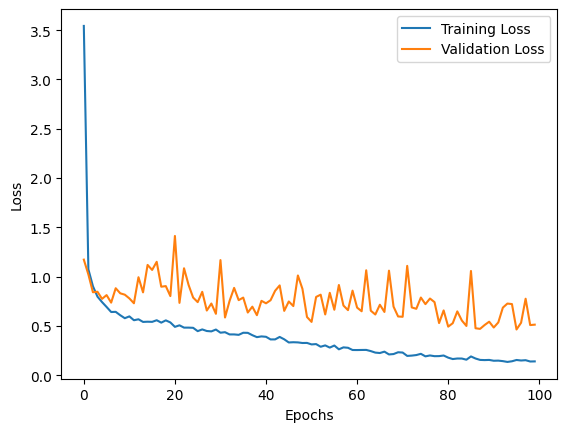

Training Metrics

Accuracy : 96.66%
              precision    recall  f1-score   support

      glioma       0.96      0.98      0.97      1400
  meningioma       0.94      0.94      0.94      1400
     notumor       0.99      0.95      0.97      1400
   pituitary       0.97      0.99      0.98      1400

    accuracy                           0.97      5600
   macro avg       0.97      0.97      0.97      5600
weighted avg       0.97      0.97      0.97      5600
 


[[1375   20    0    5]
 [  51 1314    7   28]
 [   3   52 1332   13]
 [   0    8    0 1392]]


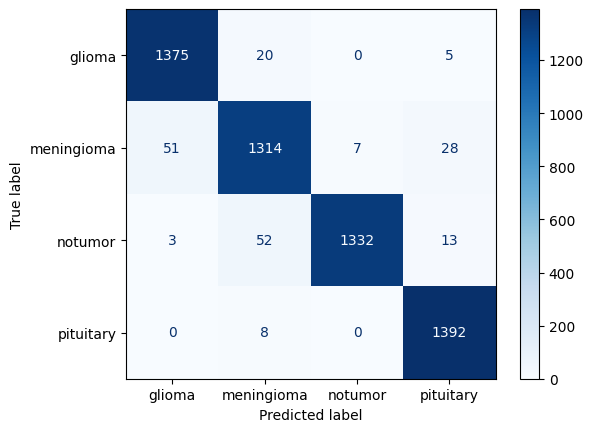

Testing Metrics

Accuracy : 91.88%
              precision    recall  f1-score   support

      glioma       0.97      0.78      0.86       400
  meningioma       0.87      0.91      0.89       400
     notumor       0.93      0.99      0.96       400
   pituitary       0.92      1.00      0.96       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600
 


[[311  50  27  12]
 [ 11 364   3  22]
 [  0   5 395   0]
 [  0   0   0 400]]


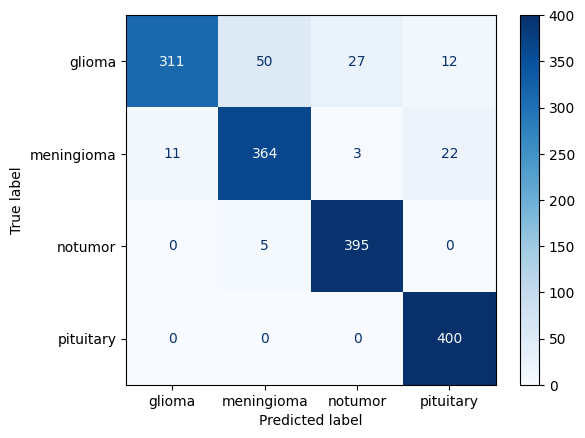

In [22]:
if __name__ == "__main__":
    main()

In [24]:
# Example Prediction

data = get_data(
    "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training",
    "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing",
    64
)

model = CNN().to(device)
model.load_state_dict(torch.load("best_model.pth", map_location=device))

predict_image( 
    model,
    "/kaggle/input/datasets/chahmed312/brain-tumor-images/Hirnmetastase_MRT-T1_KM.jpg",
    data["test_loader"].dataset.classes
)


Prediction Probabilities

glioma      : 6.44%
meningioma  : 20.69%
notumor     : 71.51%
pituitary   : 1.35%

----------------------------------
Predicted Class : notumor
